# Introduction to MODFLOW

**Instructor:** Jesus D. Gomez-Velez (jesus-gomezvelez@uiowa.edu)

MODFLOW 6 is the latest version of the U.S. Geological Survey’s modular groundwater flow model. It is designed to simulate groundwater movement in aquifers and other subsurface systems by solving equations that describe water storage and flow under a wide range of hydrogeologic conditions. In introductory groundwater courses, MODFLOW 6 is valuable because it connects fundamental concepts such as hydraulic head, Darcy’s law, continuity, aquifer properties, and boundary conditions to a practical computational framework. It is widely used to evaluate pumping, recharge, stream-aquifer interaction, and the effects of natural and human stresses on groundwater systems.

From a pedagogical perspective, MODFLOW 6 is especially useful because it is structured around a modular architecture that separates the simulation of different processes while still allowing them to interact. This makes it possible to represent groundwater flow, unsaturated-zone flow, and other coupled processes in a transparent way. Students can learn how a groundwater system is discretized into cells, how governing equations are assembled, and how numerical methods are used to estimate heads and fluxes. By exploring simple examples and then extending them to more complex settings, students gain a clear understanding of how model assumptions, parameter values, and boundary conditions influence groundwater behavior.


## Step 0. Load the required libraries

Define the exact path where our MODFLOW binaries are located. This is the directory where you have downloaded and extracted the MODFLOW executables. For example, if you have downloaded the MODFLOW 6 binaries and extracted them to a folder named `usgs_code` in your current working directory, you would set MODFLOW_BIN_DIR to `./usgs_code`. 

In [1]:
import os # Operating system library
import numpy as np # Numerical library
import matplotlib.pyplot as plt # Plotting library
import flopy # Calls modflow and other USGS programs
from flopy.plot import PlotMapView # Plotting library for MODFLOW models

MODFLOW_BIN_DIR = "/Users/jgomezvelez/.local/share/flopy/bin"
MF6_EXE = os.path.join(MODFLOW_BIN_DIR, "mf6")
MP7_EXE = os.path.join(MODFLOW_BIN_DIR, "mp7")

# Step 1. Initialize the Simulation and Time Discretization

In this step, we create the MODFLOW 6 simulation object that will contain the groundwater model and all of its packages. The `MFSimulation` object sets the model name, the MODFLOW version, the executable path, and the working directory where the simulation files will be created.

Next, we define the time discretization using `ModflowTdis`. This package specifies the number of stress periods and the duration, number of steps, and time-step multiplier for each period. In this example, we use a single stress period with a length of 1 day and one time step, which is appropriate for a simple steady-state setup.

Finally, we define the iterative solver with `ModflowIms`. This package tells MODFLOW how to solve the flow equations and sets the solver complexity. A moderate complexity is chosen to provide a good balance between robustness and computational efficiency.

Together, these objects establish the simulation framework needed before we create the groundwater-flow model itself.



In [2]:
# Model workspace and names
model_dir = "./workspace_alluvial_model"
model_name = "alluvial_model"

# Create simulation: This creates the main MODFLOW 6 simulation object and assigns it to sim. It is the container to which you’ll add the groundwater model and its packages.
sim = flopy.mf6.MFSimulation(
    sim_name=model_name, 
    version="mf6", 
    exe_name=MF6_EXE, 
    sim_ws=model_dir
)

# Define Time Discretization (TDIS) - 1 steady-state stress period
tdis = flopy.mf6.ModflowTdis(
    sim, # attaches it to the MODFLOW simulation
    nper=1, # sets one stress period.
    perioddata=[(1.0, 1, 1.0)],  # (length of period, number of steps, time step multiplier)
    time_units="DAYS"
)

# Define iterative model solver (IMS): tells MODFLOW how to solve the model’s equations.
ims = flopy.mf6.ModflowIms( 
    sim, # attaches that solver package to the simulation
    pname="ims", # gives the package the name ims.
    complexity="MODERATE" # selects FloPy/MODFLOW’s moderate preset for solver settings, such as how tightly and how quickly the solver seeks a solution. It describes the solver configuration—not the physical complexity of the groundwater model.
)

# Step 2. Create the Groundwater Flow (GWF) Model

In the next cell, we create the groundwater-flow model object (`gwf`), which is the core MODFLOW 6 component representing the aquifer system to be simulated. This model is attached to the existing simulation and assigned a name, `alluvial_model`. We also define the model name file that MODFLOW uses to keep track of this model.

At this stage, we are not yet specifying the aquifer geometry, hydraulic properties, or boundary conditions; instead, we are setting up the model container that will later receive packages such as the discretization, flow equation, and boundary-condition information. This is the foundation for the actual groundwater simulation.

In [3]:
# Create the groundwater-flow (GWF) model object. This creates a groundwater flow model and attaches it to the simulation
gwf = flopy.mf6.ModflowGwf(
    sim, # attaches the model to the simulation
    modelname=model_name, # assigns a name to the model
    model_nam_file=f"{model_name}.nam" # defines the name file used by MODFLOW to reference this model
)

# Step 3. Define the Spatial Grid (DIS)

For a regional alluvial aquifer, we will set up a 1-layer structured grid.

In [4]:
# We will use the following information from our conceptual model:

L = 20000.0  # Length of the model domain (meters)
W = 10000.0  # Width of the model domain (meters)
B = 100.0    # Thickness of the aquifer (meters)
slope_landscape = 0.0005  # Slope of the land surface (dimensionless)

# Grid dimensions (e.g., 20 km x 10 km region)
nlay = 1 # Number of layers
nrow = 100 # Number of rows
ncol = 50 # Number of columns
delr = W / ncol  # Cell width along rows (meters)
delc = L / nrow  # Cell width along columns (meters)

# Elevations

# We will create an elevation grid at cell centers for model top
minx = 0.0
maxy = L

xc = minx + (np.arange(ncol) + 0.5) * delr
yc = maxy - (np.arange(nrow) + 0.5) * delc

# Elevation varies with y and remains constant along x.
top = np.repeat((B + slope_landscape * yc)[:, np.newaxis], ncol, axis=1)
botm = top - B  # Aquifer of thickness B

dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top=top,
    botm=botm,
)

### Plot the grid and the top and bottom elevations

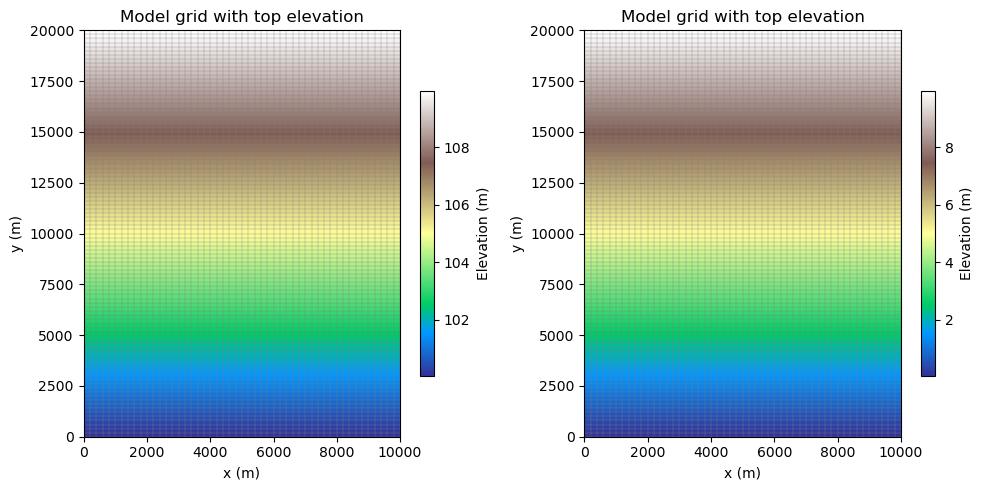

In [5]:
fig, axs = plt.subplots(1,2, figsize=(10, 5))
axs = axs.flatten()

ax = axs[0]
# Create a map view of top elevation
mv = PlotMapView(model=gwf, ax=ax)

# Plot the grid
mv.plot_grid(
    linewidth=0.25, 
    color='gray'
    )

# Plot an array (like top elevation) as colored cells
pc = mv.plot_array(
    top,
    masked_values=[],
    alpha=1.0,
    cmap='terrain',
    edgecolor='none',
    norm=None,
)


plt.colorbar(pc, ax=ax, label='Elevation (m)', shrink=0.7)
ax.set_title('Model grid with top elevation')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')

ax = axs[1]
# Create a map view of bottom elevation
mv = PlotMapView(model=gwf, ax=ax)

# Plot the grid
mv.plot_grid(
    linewidth=0.25, 
    color='gray'
    )

# Plot an array (like bottom elevation) as colored cells
pc = mv.plot_array(
    botm,
    masked_values=[],
    alpha=1.0,
    cmap='terrain',
    edgecolor='none',
    norm=None,
)


plt.colorbar(pc, ax=ax, label='Elevation (m)', shrink=0.7)
ax.set_title('Model grid with top elevation')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')

fig.tight_layout()

### Plot a cross sections in the x direction

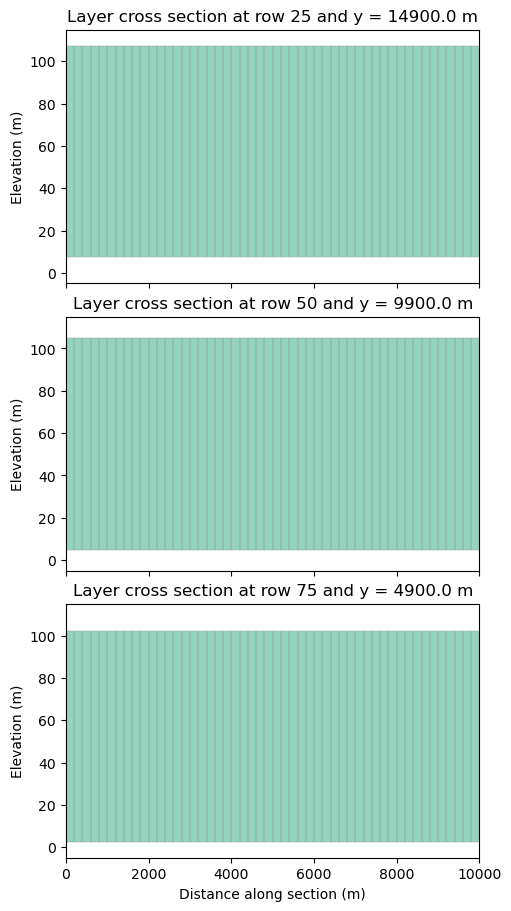

In [41]:
r_cs = (np.array([0.25, 0.50, 0.75]) * nrow).astype(int) # Plot cross sections at 25%, 50%, and 75% of the model domain in the y-direction

fig, axes = plt.subplots(
    len(r_cs), 1, figsize=(5, 3 * len(r_cs)),
    sharex=True, constrained_layout=True
)
axes = np.atleast_1d(axes)

layer_ids = np.broadcast_to(
    np.arange(1, nlay + 1)[:, None, None],
    (nlay, nrow, ncol)
).astype(float)

layer_cmap = plt.cm.Set2(np.linspace(0, 1, nlay))

for ax, r0 in zip(axes, r_cs):
    xsec = flopy.plot.PlotCrossSection(model=gwf, ax=ax, line={"row": int(r0)})

    # plot ibound first so it does not hide layer colors
    xsec.plot_ibound(alpha=0.10)

    # plot all layers
    xsec.plot_array(
        layer_ids,
        cmap=plt.cm.colors.ListedColormap(layer_cmap),
        vmin=1,
        vmax=nlay,
        alpha=0.70
    )
    xsec.plot_grid(linewidth=0.3, color="0.6")

    # force full vertical extent so all layers are visible
    ax.set_ylim(np.nanmin(botm) - 5, np.nanmax(top) + 5)

    ax.set_title(f"Layer cross section at row {int(r0)} and y = {yc[int(r0)]:.1f} m")
    ax.set_ylabel("Elevation (m)")

axes[-1].set_xlabel("Distance along section (m)")
plt.show()

### Plot a cross sections in the y direction

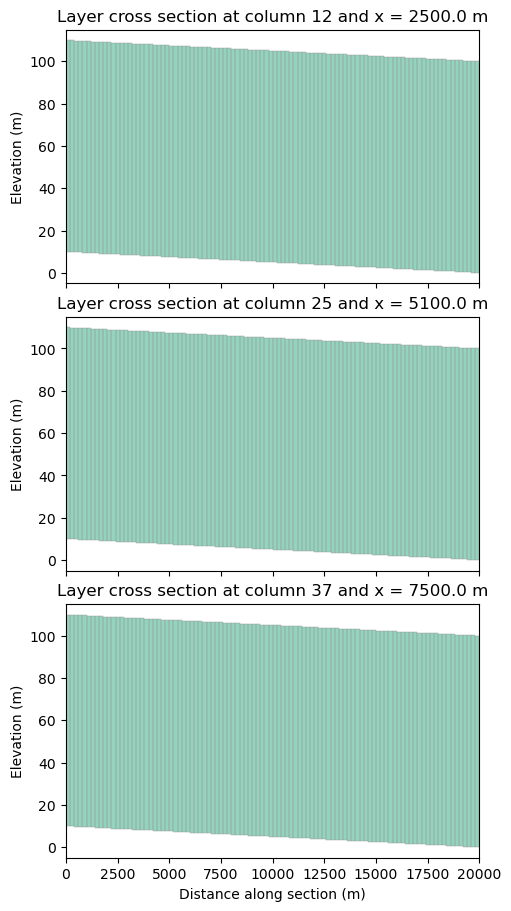

In [40]:
c_cs = (np.array([0.25, 0.50, 0.75]) * ncol).astype(int) # Plot cross sections at 25%, 50%, and 75% of the model domain in the x-direction

fig, axes = plt.subplots(
    len(c_cs), 1, figsize=(5, 3 * len(c_cs)),
    sharex=True, constrained_layout=True
)
if len(c_cs) == 1:
    axes = [axes]

layer_ids = np.broadcast_to(np.arange(1, nlay + 1)[:, None, None], (nlay, nrow, ncol)).astype(float)
layer_cmap = plt.cm.Set2(np.linspace(0, 1, nlay))

for ax, c0 in zip(axes, c_cs):
    xsec = flopy.plot.PlotCrossSection(model=gwf, ax=ax, line={"column": int(c0)})

    # plot ibound first so it does not hide layer colors
    xsec.plot_ibound(alpha=0.10)

    # plot all layers
    xsec.plot_array(
        layer_ids,
        cmap=plt.cm.colors.ListedColormap(layer_cmap),
        vmin=1, vmax=nlay, alpha=0.70
    )
    xsec.plot_grid(linewidth=0.3, color="0.6")

    # force full vertical extent so deeper layers are visible
    ax.set_ylim(np.nanmin(botm) - 5, np.nanmax(top) + 5)

    ax.set_title(f"Layer cross section at column {int(c0)} and x = {xc[int(c0)]:.1f} m")
    ax.set_ylabel("Elevation (m)")

axes[-1].set_xlabel("Distance along section (m)")
plt.show()

# Step 4. Aquifer Properties (NPF & STO)

We define the hydraulic conductivity ($K$). Since alluvial aquifers are highly permeable, we will use a value typical for sand/gravel.

In [8]:
K = 15.0  # Hydraulic conductivity (m/day)
h_0 = 95.0  # Initial head (m)

# Node Property Flow (NPF) for flow properties
npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    icelltype=1,      # 1 = Unconfined aquifer
    k=K,           # Hydraulic conductivity (m/day)
    save_flows=True,
    save_specific_discharge=True,
)

# Initial Heads
ic = flopy.mf6.ModflowGwfic(gwf, strt=h_0)

# Step 5. Boundary Conditions: The River (RIV)

Let's assume a river flows vertically down the entire left boundary (column 0) of the model.

For the River package, each cell requires: ((layer, row, col), stage, conductance, rbot)

- Stage: Water level in the river.
- Conductance ($C$): Calculated as $C = \dfrac{K_{bed} \cdot L \cdot W}{M}$ (where $L$=length, $W$=width, $M$=thickness of riverbed, $K_{bed}$ = riverbed conductivity).
- Rbot: Bottom elevation of the riverbed.

In [9]:
river_slope = slope_landscape  # m/m (drop per meter downstream). For simplicity, we will assume that the river slope is equal to the landscape slope. This is a reasonable assumption for a river that is in equilibrium with the surrounding landscape.
river_depth = 2.0           # keep river 2 m deep
cond = 500.0                # Conductance of river sediment (m^2/day)

stage_upstream = B + river_slope * L  + river_depth    # stage at row 0 (m)
stage_downstream = stage_upstream - river_slope * ((nrow-1) * delc)  # stage at last row

print(f"River stage at downstream end: {stage_downstream} m")
print(f"River stage at upstream end: {stage_upstream} m")

riv_data = []


for r in range(nrow):
    y = r * delc            # distance along river (m), since river runs by row
    stage = stage_upstream - river_slope *  y
    rbot = stage - river_depth
    riv_data.append(((0, r, ncol-1), stage, cond, rbot))

# Initialize RIV package
riv = flopy.mf6.ModflowGwfriv(
    gwf,
    pname="riv",
    maxbound=len(riv_data),
    stress_period_data={0: riv_data},
    save_flows=True
)

# Impose a constant head boundary on the top and bottom rows to simulate regional flow
chd_data = []
for c in range(ncol):
    chd_data.append(((0, 0, c), riv_data[0][1]))   # Top row 
    chd_data.append(((0, nrow-1, c), riv_data[-1][1]))  # Bottom row  

chd = flopy.mf6.ModflowGwfchd(
    gwf,
    pname="chd",
    maxbound=len(chd_data),
    stress_period_data={0: chd_data},
    save_flows=True
)


River stage at downstream end: 102.1 m
River stage at upstream end: 112.0 m


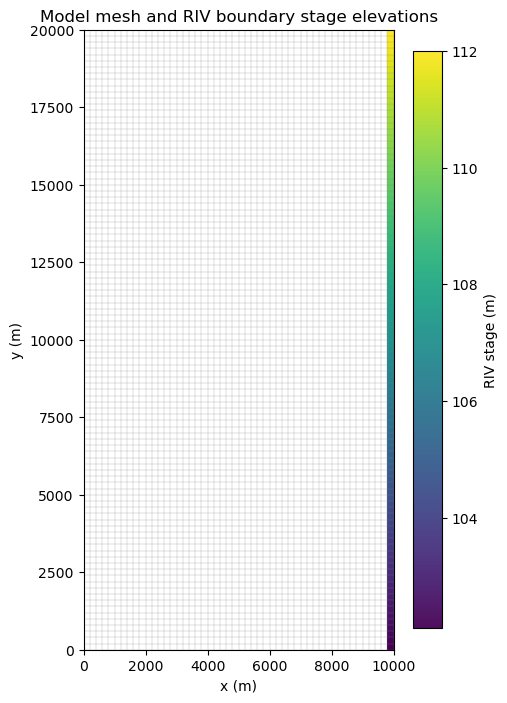

In [10]:
# Build a 2D array with river stage values at RIV cells (layer 1 / index 0)
riv_stage = np.full((nrow, ncol), np.nan, dtype=float)
for (k, r, c), stage, _, _ in riv_data:
    if k == 0:
        riv_stage[r, c] = stage

fig, ax = plt.subplots(figsize=(5, 10))
mv = PlotMapView(model=gwf, ax=ax, layer=0)

# Plot stage only where RIV is assigned
pc = mv.plot_array(
    np.ma.masked_invalid(riv_stage),
    cmap="viridis",
    alpha=0.95
)

# Plot mesh
mv.plot_grid(linewidth=0.3, color="gray", alpha=0.6)

# Optional context
# river_areas_gdf_xy_ready.boundary.plot(ax=ax, color="black", linewidth=1)

plt.colorbar(pc, ax=ax, shrink=0.75, label="RIV stage (m)")
ax.set_title("Model mesh and RIV boundary stage elevations")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_aspect("equal")
plt.show()

# fig.set_tight_layout()

# Step 6. Adding Regional Recharge (RCH)

An alluvial aquifer is usually replenished by rainfall. We'll add a uniform recharge rate across the top layer.

In [11]:
recharge_rate = 0.0001 # m/day (36.5 mm/year)

rch = flopy.mf6.ModflowGwfrcha(
    gwf, 
    recharge=recharge_rate  * 0
)

# Step 7. Adding Wells

In [12]:
# -------------------------------------------------------------
# Define Well Data
# Format: ((layer, row, col), rate)  -> rate in m^3/day
# -------------------------------------------------------------
well_data = [
    # Well 1: Pumping 
    ((0, 25, 40), -10000.0 * 0), 
    
    # Well 2: An injection well recharging the aquifer  
    ((0, 10, 30), 8000.0 * 0),
    
    # Well 3: Pumping
    ((0, 50, 25), -10000.0 )
]

# Initialize the WEL package
wel = flopy.mf6.ModflowGwfwel(
    gwf,
    pname="wel",
    maxbound=len(well_data),
    stress_period_data={0: well_data},
    save_flows=True  # Important so we can see local flow vectors change!
)

# Step 8. Output Control (OC)

In [13]:
head_file = f"{model_name}.hds"
budget_file = f"{model_name}.cbc"

oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=head_file,
    budget_filerecord=budget_file,
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")]
)

# Step 9. Run the Model

In [14]:
sim.write_simulation()
success, buff = sim.run_simulation()

if not success:
    raise RuntimeError("MODFLOW 6 did not run successfully.")

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model alluvial_model...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package riv...
    writing package chd...
    writing package rcha_0...
    writing package wel...
    writing package oc...
FloPy is using the following executable to run the model: ../../../../../.local/share/flopy/bin/mf6
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.7.0 02/05/2026

        MODFLOW 6 compiled Feb  5 2026 22:36:20 with GCC version 13.4.0

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warr

# Step 10. Post-Processing: Plotting the Results of the flow simulation

Once the simulation runs successfully, you can extract the heads and visualize how the water table interacts with the river.

In [15]:
# Load the binary head file
hds = flopy.utils.binaryfile.HeadFile(os.path.join(model_dir, head_file))
heads = hds.get_data()
cbc = flopy.utils.binaryfile.CellBudgetFile(os.path.join(model_dir, budget_file))

spdis = cbc.get_data(text="DATA-SPDIS")[0]
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(
    spdis,
    gwf,
    head=heads
)

head_min = heads.flatten().min()
head_max = heads.flatten().max()
head_step = 1 # Step size for contour levels (m)
head_range = np.arange(np.ceil(head_min*10)/10, np.floor(head_max*10)/10, head_step)
print(f"Head range: {head_min:.2f} m to {head_max:.2f} m")

Head range: 100.93 m to 112.00 m


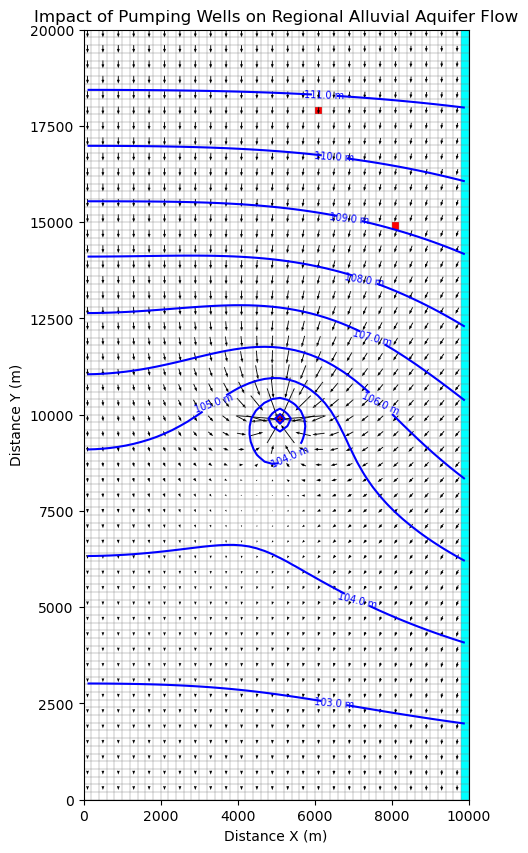

In [16]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, aspect="equal")

# modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax)
pmv = flopy.plot.PlotMapView(model=gwf, ax=ax)

# 1. Plot the grid and boundary conditions (River in Cyan, Wells in Red)
pmv.plot_ibound()
pmv.plot_grid(colors="0.5", lw=0.3)      # mesh lines
pmv.plot_bc("RIV", color="cyan")
pmv.plot_bc("WEL", color="red")  # This automatically plots your well locations

# 2. Plot head contours
contours = pmv.contour_array(heads[0], colors="blue", levels=head_range)
plt.clabel(contours, inline=True, fmt="%1.1f m", fontsize=7)

# 3. Plot the flow vectors
# We turn normalize=False here so you can visually see the groundwater 
# accelerate (longer arrows) as it gets sucked into the pumping wells.

vectors = pmv.plot_vector(
    qx, 
    qy, 
    istep=2, 
    jstep=2, 
    normalize=False,   
    color="black", 
    scale=.5,         # You may need to tweak the scale if arrows are too long/short
    headwidth=3, 
    headlength=4
)

ax.set_title("Impact of Pumping Wells on Regional Alluvial Aquifer Flow")
ax.set_xlabel("Distance X (m)")
ax.set_ylabel("Distance Y (m)")
plt.show()

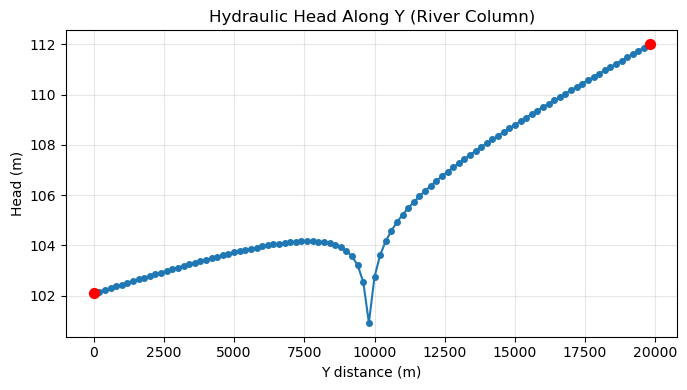

In [17]:
# Head profile along y for the first column (col = 0)

the_col = 25

head_col_river = heads[0, :, the_col]  # Extract head values along the first column (river side)
y_vals = (nrow - np.arange(nrow) - 1)* delc  # y-distance in meters

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(y_vals, head_col_river, marker="o", linewidth=1.5, markersize=4, label="Hydraulic Head")
y_upstream = (nrow-1) * delc
y_downstream = 0
ax.scatter([y_upstream, y_downstream], [stage_upstream, stage_downstream], color="red", s=50, zorder=5)  # Highlight points with red dots
ax.set_xlabel("Y distance (m)")
ax.set_ylabel("Head (m)")
ax.set_title("Hydraulic Head Along Y (River Column)")
ax.grid(True, alpha=0.3)
fig.tight_layout()

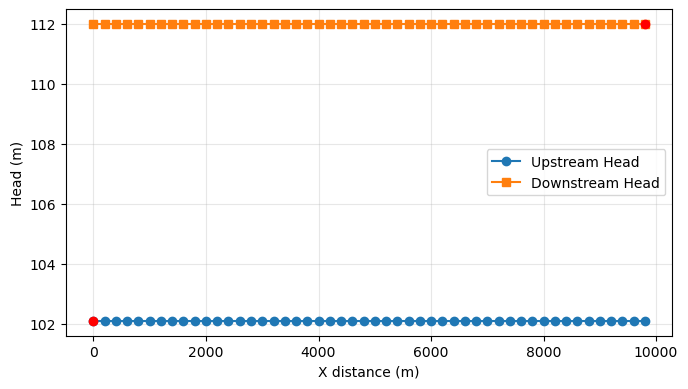

In [18]:
# Head profile along y for the first column (col = 0)
head_row_upstream = heads[0, nrow-1, :]  # Extract head values along the upstream row 
head_row_downstream = heads[0, 0, :]    # Extract head values along the downstream row 

x_vals = np.arange(ncol) * delc  # x-distance in meters

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_vals, head_row_upstream, marker="o", linewidth=1.5, label="Upstream Head")
ax.plot(x_vals, head_row_downstream, marker="s", linewidth=1.5, label="Downstream Head")
x_upstream = (ncol-1) * delc
x_downstream = 0
ax.scatter([x_upstream, x_downstream], [stage_upstream, stage_downstream], color="red", zorder=5)  # Highlight points with red dots
ax.set_xlabel("X distance (m)")
ax.set_ylabel("Head (m)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

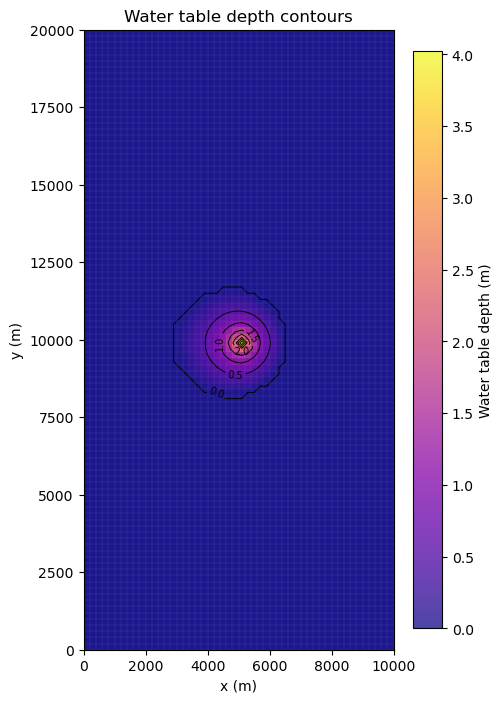

In [19]:
# Water table depth (m) = land surface (top) - water table elevation
if "wt_elev" in globals():
    wt = wt_elev
else:
    hmask = np.ma.masked_where(heads < 0, heads)
    wt = np.nanmax(hmask, axis=0)

wt_depth = top - wt
wt_depth = np.where(np.isfinite(wt_depth), np.maximum(wt_depth, 0.0), np.nan)

wt_depth_ma = np.ma.masked_invalid(wt_depth)
levels = np.arange(0, np.max(wt_depth) + 1, 0.5)

fig, ax = plt.subplots(figsize=(5, 10))
pmv = PlotMapView(model=gwf, ax=ax, layer=0)

# Optional background
pc = pmv.plot_array(wt_depth_ma, cmap="plasma", alpha=0.75)

# Define color range (clip to robust upper bound)
vmin = 0.0
vmax = np.max(wt_depth)
pc.set_clim(vmin=vmin, vmax=vmax)
# Contour lines
cs = pmv.contour_array(wt_depth_ma, levels=levels, colors="black", linewidths=0.7)
ax.clabel(cs, fmt="%.1f", fontsize=7)

pmv.plot_grid(linewidth=0.2, color="0.7", alpha=0.4)


plt.colorbar(pc, ax=ax, shrink=0.75, label="Water table depth (m)")
ax.set_title("Water table depth contours")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_aspect("equal")
plt.show()

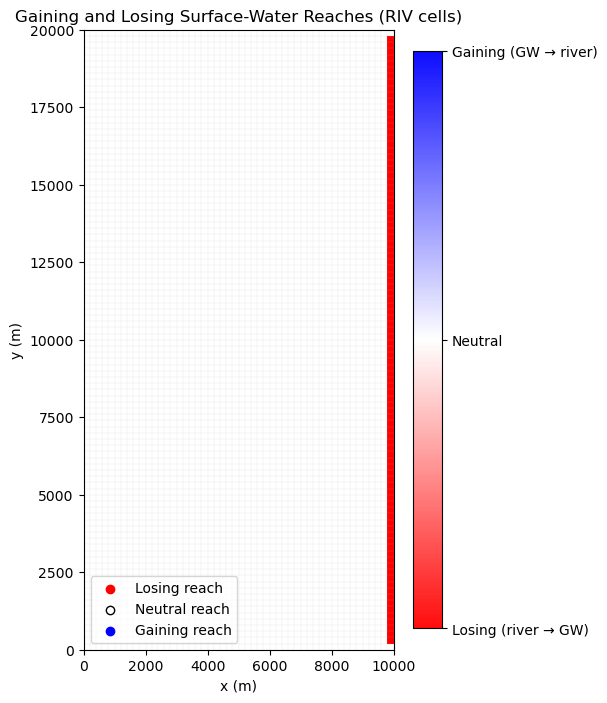

In [20]:
# Map of gaining/losing surface-water exchange at RIV cells
# Convention:
#   +1  -> gaining stream (GW -> river; aquifer head > river stage)
#   -1  -> losing stream  (river -> GW; aquifer head < river stage)
#    0  -> near-neutral

tol = 1e-3  # m
riv_exchange = np.full((nrow, ncol), np.nan, dtype=float)

for (k, r, c), stage, _, _ in riv_data:
    h = heads[k, r, c]
    if not np.isfinite(h) or h < 0:
        continue
    if h > stage + tol:
        riv_exchange[r, c] = 1.0
    elif h < stage - tol:
        riv_exchange[r, c] = -1.0
    else:
        riv_exchange[r, c] = 0.0

fig, ax = plt.subplots(figsize=(5, 10))
pmv = PlotMapView(model=gwf, ax=ax, layer=0)

arr = np.ma.masked_invalid(riv_exchange)
pc = pmv.plot_array(arr, cmap="bwr_r", vmin=-1, vmax=1, alpha=0.95)
pmv.plot_grid(linewidth=0.2, color="0.75", alpha=0.5)



cbar = plt.colorbar(pc, ax=ax, shrink=0.75, ticks=[-1, 0, 1])
cbar.ax.set_yticklabels(["Losing (river → GW)", "Neutral", "Gaining (GW → river)"])

# Legend proxies
ax.scatter([], [], c="red", label="Losing reach")
ax.scatter([], [], c="white", edgecolor="k", label="Neutral reach")
ax.scatter([], [], c="blue", label="Gaining reach")
ax.legend(loc="lower left", frameon=True)

ax.set_title("Gaining and Losing Surface-Water Reaches (RIV cells)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_aspect("equal")
plt.show()

In [21]:
print(gwf.packagelist)

[package_name = dis
filename = alluvial_model.dis
package_type = dis
model_or_simulation_package = model
model_name = alluvial_model

Block dimensions
--------------------
nlay
{internal}
(1)

nrow
{internal}
(100)

ncol
{internal}
(50)


Block griddata
--------------------
delr
{constant 200.0}

delc
{constant 200.0}

top
{internal}
(array([[109.95, 109.95, 109.95, ..., 109.95, 109.95, 109.95],
       [109.85, 109.85, 109.85, ..., 109.85, 109.85, 109.85],
       [109.75, 109.75, 109.75, ..., 109.75, 109.75, 109.75],
       ...,
       [100.25, 100.25, 100.25, ..., 100.25, 100.25, 100.25],
       [100.15, 100.15, 100.15, ..., 100.15, 100.15, 100.15],
       [100.05, 100.05, 100.05, ..., 100.05, 100.05, 100.05]],
      shape=(100, 50)))

botm
{internal}
(array([[[9.95, 9.95, 9.95, ..., 9.95, 9.95, 9.95],
        [9.85, 9.85, 9.85, ..., 9.85, 9.85, 9.85],
        [9.75, 9.75, 9.75, ..., 9.75, 9.75, 9.75],
        ...,
        [0.25, 0.25, 0.25, ..., 0.25, 0.25, 0.25],
        [0.15, 0.15

## Step 11. Capture Zone for Each Pumping Well

Approximate capture zones are computed by using MODPATH 7. MODPATH is a particle-tracking code that uses the heads and cell-by-cell flows from the MODFLOW 6 solution to follow the path of imaginary water particles. The next cell does the following:

1. **Initialize MODPATH 7.** `Modpath7` links MODPATH to the MODFLOW flow model (`gwf`) and to the model workspace, so it can read the flow results.
2. **Set basic properties.** `Modpath7Bas` assigns an effective porosity of 0.25, which controls the particle travel speed (velocity = flux / porosity).
3. **Place particles at the pumping wells.** The loop selects the wells with a non-zero pumping rate and converts each well's (layer, row, column) location to a global cell number. Each of those cells is subdivided into a 10 x 10 x 1 grid of particles (100 particles per well).
4. **Configure the tracking simulation.** Pathlines are computed with `trackingdirection="backward"`, meaning particles are tracked *upgradient from the well* to show where the pumped water comes from. The area covered by these pathlines approximates the well's capture zone. Particles stop when they reach a weak sink or a weak source cell.
5. **Write and run.** `mp.write_input()` writes the MODPATH input files and `mp.run_model()` runs the particle tracking. The output reports how many particles ended at each type of boundary or source/sink cell, and `(True, [])` indicates the run finished successfully.

The resulting pathlines are plotted in the next cells.

In [32]:
# Name for the MODPATH files
mp_name = f"{model_name}_mp"

# -------------------------------------------------------------
# 1. Initialize the MODPATH 7 simulation
# -------------------------------------------------------------

mp = flopy.modpath.Modpath7(
    modelname=mp_name, 
    flowmodel=gwf, 
    exe_name="mp7", 
    model_ws=model_dir
)

# -------------------------------------------------------------
# 2. Set up the MODPATH execution options
# -------------------------------------------------------------

# we use 'backwards' tracking to see where the well's water originates!
mpbas = flopy.modpath.Modpath7Bas(mp, porosity=0.25)

# -------------------------------------------------------------
# 3. Create particles around the wells (FIXED)
# -------------------------------------------------------------
node_numbers = []
for well in well_data:
    if np.abs(well[1]) > 1e-6:  # Include only pumping wells with a rate below the tolerance
        print(f"Creating particles for well at layer {well[0][0]}, row {well[0][1]}, col {well[0][2]} with rate {well[1]} m^3/day")
        # Get the global node number for the well cell
        layer, row, col = well[0]
        node = gwf.modelgrid.get_node([(layer, row, col)])[0]
        node_numbers.append(node)

# Set up the cell data type template to place an array of particles in the cell
# 2x2x1 means 4 particles distributed inside each well cell
subdivision_data = flopy.modpath.CellDataType(
    drape=0, 
    columncelldivisions=10, 
    rowcelldivisions=10, 
    layercelldivisions=1
)

# Initialize the node particle data object
node_particle_data = flopy.modpath.NodeParticleData(
    subdivisiondata=subdivision_data,
    nodes=np.asarray(node_numbers, dtype=int),
)

# Wrap it into a Particle Group Node Template
pg = flopy.modpath.ParticleGroupNodeTemplate(
    particlegroupname="well_particles", 
    particledata=node_particle_data
)

# -------------------------------------------------------------
# 4. Configure the tracking simulation
# -------------------------------------------------------------
mpsim = flopy.modpath.Modpath7Sim(
    mp,
    simulationtype="pathline",
    trackingdirection="backward",  # Track backward from the well
    weaksinkoption="stop_at",      # Tells particles to stop when they reach a well
    weaksourceoption="stop_at",
    budgetoutputoption="summary",
    particlegroups=pg,
)

# -------------------------------------------------------------
# 5. Write input files and run MODPATH
# -------------------------------------------------------------
mp.write_input()
mp.run_model()

Creating particles for well at layer 0, row 50, col 25 with rate -10000.0 m^3/day
FloPy is using the following executable to run the model: ../../../../../.local/share/flopy/bin/mp7

MODPATH Version 7.2.001   
Program compiled May 26 2026 17:12:29 with GFORTRAN compiler (ver. 12.5.0)      


Run particle tracking simulation ...
Processing Time Step     1 Period     1.  Time =  1.00000E+00  Steady-state flow                                                    

Particle Summary:
         0 particles are pending release.
         0 particles remain active.
         0 particles terminated at boundary faces.
         0 particles terminated at weak sink cells.
        23 particles terminated at weak source cells.
        77 particles terminated at strong source/sink cells.
         0 particles terminated in cells with a specified zone number.
         0 particles were stranded in inactive or dry cells.
         0 particles were unreleased.
         0 particles have an unknown status.
 
Norma

(True, [])

### Plot the results of the particle tracking

Text(0, 0.5, 'Distance Y (m)')

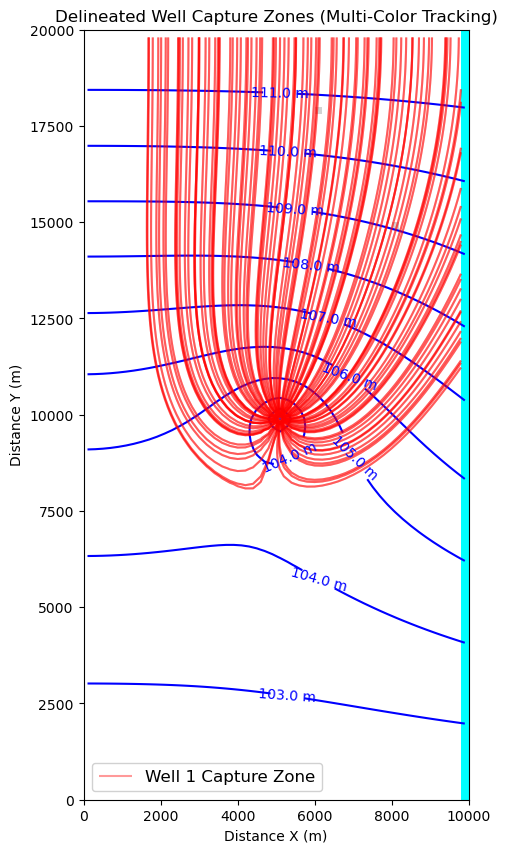

In [34]:
# 1. Load the pathline data
pathline_file = os.path.join(model_dir, f"{mp_name}.mppth")
p = flopy.utils.PathlineFile(pathline_file)

# Define a list of distinct colors for your wells
# (Add more colors if you add more wells later!)
capture_zone_colors = ["red", "darkorange", "purple", "green", "magenta"]

# 2. Set up the Map View
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, aspect="equal")
modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax)

# Plot standard features
modelmap.plot_ibound()
modelmap.plot_bc("RIV", color="cyan")

# 1. This tints the well cell background subtly so you know which cell it is
modelmap.plot_bc("WEL", color="lightgray")

# Plot Head Contours
contours = modelmap.contour_array(heads[0], colors="blue", levels=head_range)
plt.clabel(contours, inline=True, fmt="%1.1f m", fontsize=10)

# Loop through each well and plot its pathlines with a unique color
for i, node in enumerate(node_numbers):
    # Extract pathlines strictly bound for this specific well node
    well_pathlines = p.get_destination_pathline_data(node)
    
    # Pick a color from our list (wrap around using modulo if there are more wells than colors)
    color = capture_zone_colors[i % len(capture_zone_colors)]
    
    # Plot this specific well's pathlines
    # (Note: travel_time parameter is omitted entirely to avoid parsing errors)
    modelmap.plot_pathline(
        well_pathlines, 
        colors= color, 
        linewidth=1.5, 
        alpha=0.4,
        label=f"Well {i+1} Capture Zone"
    )

# Add a legend to easily identify which zone belongs to which well
ax.legend(loc="lower left", fontsize=12, framealpha=0.9)

ax.set_title("Delineated Well Capture Zones (Multi-Color Tracking)")
ax.set_xlabel("Distance X (m)")
ax.set_ylabel("Distance Y (m)")

### Capture zone disciminating the source of the water 

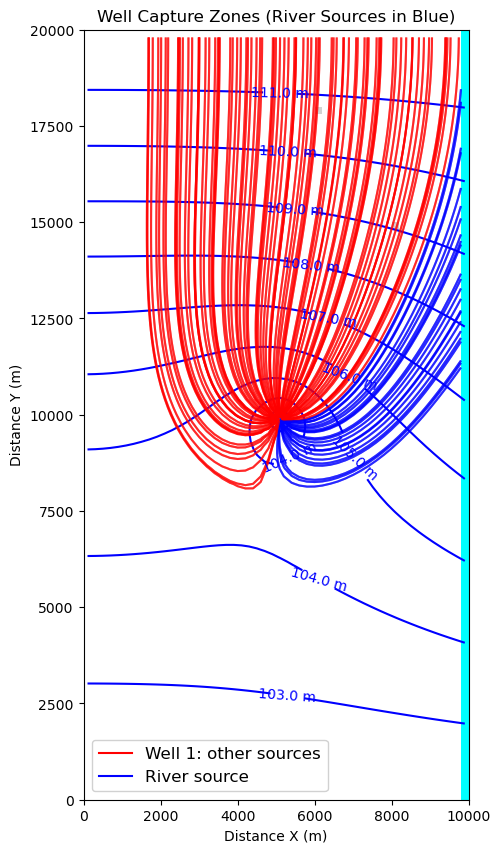

In [38]:
# Load the pathline data
pathline_file = os.path.join(model_dir, f"{mp_name}.mppth")
p = flopy.utils.PathlineFile(pathline_file)

capture_zone_colors = ["red", "darkorange", "purple", "green", "magenta"]
river_origin_color = "blue"

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect("equal")
modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax)

modelmap.plot_ibound()
modelmap.plot_bc("RIV", color="cyan")
modelmap.plot_bc("WEL", color="lightgray")

contours = modelmap.contour_array(heads[0], colors="blue", levels=head_range)
plt.clabel(contours, inline=True, fmt="%1.1f m", fontsize=10)

legend_handles = []

for i, node in enumerate(node_numbers):
    well_color = capture_zone_colors[i % len(capture_zone_colors)]
    well_pathlines = p.get_destination_pathline_data(node)

    for pathline in well_pathlines:
        # In backward tracking, the final point indicates the particle's source.
        x_end = pathline["x"][-1]
        y_end = pathline["y"][-1]

        ends_at_river = (
            (ncol - 1) * delr <= x_end <= ncol * delr
            and 0 <= y_end <= L
        )
        color = river_origin_color if ends_at_river else well_color

        modelmap.plot_pathline(
            pathline,
            colors=color,
            linewidth=1.5,
            alpha=0.6,
        )

    legend_handles.append(
        ax.plot([], [], color=well_color, label=f"Well {i + 1}: other sources")[0]
    )

legend_handles.append(
    ax.plot([], [], color=river_origin_color, label="River source")[0]
)
ax.legend(handles=legend_handles, loc="lower left", fontsize=12, framealpha=0.9)

ax.set_title("Well Capture Zones (River Sources in Blue)")
ax.set_xlabel("Distance X (m)")
ax.set_ylabel("Distance Y (m)")
plt.show()